# Machine Unlearning Technique Comparison

Comparative analysis of **Exact Retraining**, **Gradient Ascent**, and **First-Epoch Reversal** unlearning methods.

This notebook compares three unlearning approaches:
- **Exact Retraining** (Gold Standard): Retrain on retain set only
- **Gradient Ascent** (Approximation): Fast approximation via gradient ascent on delete set
- **First-Epoch Reversal** (Checkpoint-based): Rewind to early checkpoint and retrain

Metrics compared: Forgetting (privacy), Utility (retained accuracy), and Efficiency (time)

In [21]:
import json
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Aggregate Results Across Seeds/Delete Ratios

In [22]:
# Multi-seed / multi-delete-ratio aggregation configuration
SEEDS = [42, 123, 999]
DELETE_RATIOS = [0.01, 0.05, 0.10]
DATASETS = ["MNIST", "CIFAR10", "CIFAR100"]

# Correct path: go up from notebooks/analysis to workspace root, then to results
RESULTS_DIR = Path("../../results/metadata").resolve()
AGGREGATED_OUTPUT_DIR = Path("aggregated")
AGGREGATED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def format_delete_ratio(delete_ratio):
    """Format delete ratio as string for filename matching (e.g., 0.01 -> '0.01', 0.10 -> '0.1')"""
    return f"{delete_ratio:.4f}".rstrip("0").rstrip(".")

def format_delete_ratio_compact(delete_ratio):
    """Format delete ratio with 'p' separator (e.g., 0.01 -> '0p01', 0.10 -> '0p1')"""
    return f"{delete_ratio:.4f}".rstrip("0").rstrip(".").replace(".", "p")

def dataset_prefix(dataset_tag):
    tag = (dataset_tag or "").strip()
    if not tag or tag.upper() == "MNIST":
        return ""
    return f"{tag}_"

def candidate_files(dataset_tag, seed, delete_ratio):
    """Generate all candidate file paths for this seed/ratio/dataset combo"""
    seed_str = f"{seed:04d}"
    ratio_str = format_delete_ratio(delete_ratio)  # e.g., "0.01", "0.1"
    ratio_p_str = format_delete_ratio_compact(delete_ratio)  # e.g., "0p01", "0p1"
    prefix = dataset_prefix(dataset_tag)

    # Gradient Ascent / Exact candidates (unlearning_seed files)
    gradient_candidates = [
        RESULTS_DIR / f"{prefix}unlearning_seed_{seed_str}_{ratio_str}_results.json",
    ]

    # First Epoch Reversal candidates
    first_epoch_candidates = [
        RESULTS_DIR / f"{prefix}first_epoch_reversal_seed_{seed_str}_{ratio_p_str}_results.json",
    ]

    return gradient_candidates, first_epoch_candidates

def load_json_file(path):
    """Load JSON file safely"""
    if path and isinstance(path, Path) and path.exists():
        with path.open("r") as f:
            return json.load(f)
    return None

def pick_metric(mapping, *keys):
    """Get first non-None value from mapping for any of the given keys"""
    for key in keys:
        value = mapping.get(key)
        if value is not None and not isinstance(value, dict):
            return value
    return None

# Aggregate data for all datasets
all_aggregated_dfs = {}

for DATASET_TAG in DATASETS:
    print(f"\n{'='*80}")
    print(f"Aggregating results for {DATASET_TAG} across seeds {SEEDS} and delete_ratios {DELETE_RATIOS}")
    print(f"{'='*80}")
    print(f"Results directory: {RESULTS_DIR}")
    print(f"Directory exists: {RESULTS_DIR.exists()}")
    print()

    raw_rows = []
    files_found = {"gradient": 0, "reversal": 0}
    files_missing = []
    exact_times = []  # Store exact times to compute speedups for reversal

    for delete_ratio in DELETE_RATIOS:
        for seed in SEEDS:
            grad_cands, rev_cands = candidate_files(DATASET_TAG, seed, delete_ratio)
            
            # Try to load gradient ascent / exact pair
            grad_path = next((p for p in grad_cands if p.exists()), None)
            grad_data = load_json_file(grad_path)
            exact_time = None
            
            if grad_data:
                files_found["gradient"] += 1
                
                # Extract exact retraining metrics
                exact = grad_data.get("exact_unlearning", {})
                exact_time = exact.get("train_time_seconds")
                if exact_time:
                    exact_times.append((delete_ratio, seed, exact_time))
                
                raw_rows.append({
                    "method": "Exact Retraining",
                    "delete_ratio": delete_ratio,
                    "seed": seed,
                    "test_acc": exact.get("test_accuracy"),
                    "retain_acc": exact.get("retain_set_accuracy"),
                    "delete_acc": exact.get("delete_set_accuracy"),
                    "delete_loss": exact.get("delete_set_loss"),
                    "forgetting_score": exact.get("forgetting_score"),
                    "time_seconds": exact_time,
                    "speedup": 1.0,
                    "l2_abs": 0.0,
                    "l2_rel": 0.0,
                    "mia_accuracy": grad_data.get("privacy_evaluation_mia", {}).get("baseline_model", {}).get("mia_accuracy"),
                    "privacy_gain": 0.0,
                })
                
                # Extract gradient ascent metrics
                approx = grad_data.get("approx_unlearning", {})
                approx_time = approx.get("train_time_seconds")
                speedup = (exact_time / approx_time) if exact_time and approx_time and approx_time > 0 else None
                distance_metrics = approx.get("distance_metrics", {})
                
                raw_rows.append({
                    "method": "Gradient Ascent",
                    "delete_ratio": delete_ratio,
                    "seed": seed,
                    "test_acc": approx.get("test_accuracy"),
                    "retain_acc": approx.get("retain_set_accuracy"),
                    "delete_acc": approx.get("delete_set_accuracy"),
                    "delete_loss": approx.get("delete_set_loss"),
                    "forgetting_score": approx.get("forgetting_score"),
                    "time_seconds": approx_time,
                    "speedup": speedup,
                    "l2_abs": distance_metrics.get("l2_absolute"),
                    "l2_rel": distance_metrics.get("l2_relative"),
                    "mia_accuracy": grad_data.get("privacy_evaluation_mia", {}).get("after_unlearning", {}).get("mia_accuracy"),
                    "privacy_gain": grad_data.get("privacy_evaluation_mia", {}).get("privacy_gain"),
                })
            else:
                files_missing.append({
                    "type": "gradient",
                    "seed": seed,
                    "ratio": delete_ratio,
                    "expected": grad_cands[0] if grad_cands else None,
                })
            
            # Try to load first epoch reversal
            rev_path = next((p for p in rev_cands if p.exists()), None)
            rev_data = load_json_file(rev_path)
            
            if rev_data:
                files_found["reversal"] += 1
                
                fer = rev_data.get("first_epoch_reversal", {})
                metrics = fer.get("metrics", {})
                fer_time = fer.get("time_seconds")
                distance = fer.get("distance_metrics", {})
                privacy_eval = rev_data.get("privacy_evaluation", {})
                
                # Get speedup relative to exact time for this delete_ratio
                speedup = None
                if exact_time and fer_time and fer_time > 0:
                    speedup = exact_time / fer_time
                
                raw_rows.append({
                    "method": "First-Epoch Reversal",
                    "delete_ratio": delete_ratio,
                    "seed": seed,
                    "test_acc": None,  # Not available in reversal
                    "retain_acc": metrics.get("retained_accuracy"),
                    "delete_acc": metrics.get("deleted_accuracy"),
                    "delete_loss": metrics.get("deleted_loss"),
                    "forgetting_score": None,  # Skip per-class dict, extract only scalar if available
                    "time_seconds": fer_time,
                    "speedup": speedup,
                    "l2_abs": distance.get("l2_absolute"),
                    "l2_rel": distance.get("l2_relative"),
                    "mia_accuracy": privacy_eval.get("mia_unlearned", {}).get("mia_accuracy"),
                    "privacy_gain": privacy_eval.get("privacy_improvement"),
                })
            else:
                files_missing.append({
                    "type": "reversal",
                    "seed": seed,
                    "ratio": delete_ratio,
                    "expected": rev_cands[0] if rev_cands else None,
                })

    # Create dataframe from raw rows
    df_raw = pd.DataFrame(raw_rows)

    # Summary statistics
    print(f"✓ Loaded gradient ascent files: {files_found['gradient']} / {len(SEEDS) * len(DELETE_RATIOS)}")
    print(f"✓ Loaded first-epoch reversal files: {files_found['reversal']} / {len(SEEDS) * len(DELETE_RATIOS)}")
    print(f"✓ Total rows collected: {len(df_raw)}")

    if files_missing:
        print(f"⚠ Missing file groups: {len(files_missing)}")

    # Aggregate by method and delete_ratio, computing mean and std for all metrics
    if not df_raw.empty:
        metric_cols = ["test_acc", "retain_acc", "delete_acc", "delete_loss", "forgetting_score", 
                       "time_seconds", "speedup", "l2_abs", "l2_rel", "mia_accuracy", "privacy_gain"]
        
        agg_dict = {col: ["mean", "std"] for col in metric_cols}
        aggregated_df = df_raw.groupby(["method", "delete_ratio"], as_index=False).agg(agg_dict)
        
        # Flatten and rename columns
        new_cols = ["method", "delete_ratio"]
        for col in metric_cols:
            new_cols.extend([f"{col}_mean", f"{col}_std"])
        
        aggregated_df.columns = new_cols
    else:
        new_cols = ["method", "delete_ratio"]
        for col in ["test_acc", "retain_acc", "delete_acc", "delete_loss", "forgetting_score", 
                    "time_seconds", "speedup", "l2_abs", "l2_rel", "mia_accuracy", "privacy_gain"]:
            new_cols.extend([f"{col}_mean", f"{col}_std"])
        aggregated_df = pd.DataFrame(columns=new_cols)

    aggregated_df = aggregated_df.sort_values(["method", "delete_ratio"]).reset_index(drop=True)

    # Save to CSV
    csv_path = AGGREGATED_OUTPUT_DIR / f"{DATASET_TAG}_centralized_summary.csv"
    aggregated_df.to_csv(csv_path, index=False)
    
    # Store for later loading/plotting
    all_aggregated_dfs[DATASET_TAG] = aggregated_df

    print(f"\n✓ Aggregated summary saved to: {csv_path}")
    print(f"  DataFrame shape: {aggregated_df.shape}")
    print(f"  Columns ({len(aggregated_df.columns)}): {list(aggregated_df.columns)}")

print(f"\n{'='*80}")
print(f"✓ All datasets aggregated successfully!")
print(f"{'='*80}")
print(f"\nGenerated CSV files:")
for dataset in DATASETS:
    csv_path = AGGREGATED_OUTPUT_DIR / f"{dataset}_centralized_summary.csv"
    print(f"  - {csv_path}")


Aggregating results for MNIST across seeds [42, 123, 999] and delete_ratios [0.01, 0.05, 0.1]
Results directory: /Users/new/Desktop/unlearning/results/metadata
Directory exists: True

✓ Loaded gradient ascent files: 9 / 9
✓ Loaded first-epoch reversal files: 9 / 9
✓ Total rows collected: 27

✓ Aggregated summary saved to: aggregated/MNIST_centralized_summary.csv
  DataFrame shape: (9, 24)
  Columns (24): ['method', 'delete_ratio', 'test_acc_mean', 'test_acc_std', 'retain_acc_mean', 'retain_acc_std', 'delete_acc_mean', 'delete_acc_std', 'delete_loss_mean', 'delete_loss_std', 'forgetting_score_mean', 'forgetting_score_std', 'time_seconds_mean', 'time_seconds_std', 'speedup_mean', 'speedup_std', 'l2_abs_mean', 'l2_abs_std', 'l2_rel_mean', 'l2_rel_std', 'mia_accuracy_mean', 'mia_accuracy_std', 'privacy_gain_mean', 'privacy_gain_std']

Aggregating results for CIFAR10 across seeds [42, 123, 999] and delete_ratios [0.01, 0.05, 0.1]
Results directory: /Users/new/Desktop/unlearning/results/met

In [23]:
# Load all three aggregated CSV files
aggregated_data = {}

print("="*80)
print("Loading aggregated CSV files for all datasets")
print("="*80)

for dataset in DATASETS:
    csv_path = AGGREGATED_OUTPUT_DIR / f"{dataset}_centralized_summary.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        aggregated_data[dataset] = df
        print(f"\n✓ {dataset}: Loaded {df.shape[0]} rows × {df.shape[1]} columns")
        print(f"  Methods: {df['method'].unique().tolist()}")
        print(f"  Delete ratios: {sorted(df['delete_ratio'].unique().tolist())}")
    else:
        print(f"\n✗ {dataset}: CSV file not found at {csv_path}")

print(f"\n{'='*80}")
print(f"✓ All datasets loaded. Ready for plotting!")
print(f"{'='*80}")
print(f"\nAvailable dataframes for plotting:")
for dataset in aggregated_data.keys():
    print(f"  - aggregated_data['{dataset}']")


Loading aggregated CSV files for all datasets

✓ MNIST: Loaded 9 rows × 24 columns
  Methods: ['Exact Retraining', 'First-Epoch Reversal', 'Gradient Ascent']
  Delete ratios: [0.01, 0.05, 0.1]

✓ CIFAR10: Loaded 9 rows × 24 columns
  Methods: ['Exact Retraining', 'First-Epoch Reversal', 'Gradient Ascent']
  Delete ratios: [0.01, 0.05, 0.1]

✓ CIFAR100: Loaded 9 rows × 24 columns
  Methods: ['Exact Retraining', 'First-Epoch Reversal', 'Gradient Ascent']
  Delete ratios: [0.01, 0.05, 0.1]

✓ All datasets loaded. Ready for plotting!

Available dataframes for plotting:
  - aggregated_data['MNIST']
  - aggregated_data['CIFAR10']
  - aggregated_data['CIFAR100']


In [24]:
print(aggregated_data['MNIST'].head(5))

                 method  delete_ratio  test_acc_mean  test_acc_std  \
0      Exact Retraining          0.01       0.981767      0.000850   
1      Exact Retraining          0.05       0.982467      0.001106   
2      Exact Retraining          0.10       0.981867      0.001514   
3  First-Epoch Reversal          0.01            NaN           NaN   
4  First-Epoch Reversal          0.05            NaN           NaN   

   retain_acc_mean  retain_acc_std  delete_acc_mean  delete_acc_std  \
0         0.997110        0.001041         0.978889        0.002546   
1         0.998275        0.001272         0.979667        0.004041   
2         0.997864        0.001323         0.981000        0.001302   
3         0.989961        0.001387         0.976667        0.002887   
4         0.990076        0.001042         0.978889        0.001262   

   delete_loss_mean  delete_loss_std  ...  speedup_mean  speedup_std  \
0          0.078732         0.010460  ...      1.000000     0.000000   
1       

## 3. Utility vs Unlearning Trade-off Plots

In [25]:
# Select dataset and prepare data
SELECTED_DATASET = 'MNIST'
df = aggregated_data[SELECTED_DATASET].copy()

# Ensure methods are consistent and ordered
method_order = ["Exact Retraining", "Gradient Ascent", "First-Epoch Reversal"]
df = df[df["method"].isin(method_order)]

# Sort values for proper line plotting
df = df.sort_values(by=["method", "delete_ratio"])

print(f"Dataset: {SELECTED_DATASET}")
print(f"Methods: {df['method'].unique().tolist()}")
print(f"Delete ratios: {sorted(df['delete_ratio'].unique().tolist())}")
print(f"DataFrame shape: {df.shape}")
print("\nData preview:")
print(df[["method", "delete_ratio", "test_acc_mean", "retain_acc_mean", "delete_acc_mean"]].head(10))

Dataset: MNIST
Methods: ['Exact Retraining', 'First-Epoch Reversal', 'Gradient Ascent']
Delete ratios: [0.01, 0.05, 0.1]
DataFrame shape: (9, 24)

Data preview:
                 method  delete_ratio  test_acc_mean  retain_acc_mean  \
0      Exact Retraining          0.01       0.981767         0.997110   
1      Exact Retraining          0.05       0.982467         0.998275   
2      Exact Retraining          0.10       0.981867         0.997864   
3  First-Epoch Reversal          0.01            NaN         0.989961   
4  First-Epoch Reversal          0.05            NaN         0.990076   
5  First-Epoch Reversal          0.10            NaN         0.989494   
6       Gradient Ascent          0.01       0.983167         0.998586   
7       Gradient Ascent          0.05       0.983133         0.998550   
8       Gradient Ascent          0.10       0.983100         0.998537   

   delete_acc_mean  
0         0.978889  
1         0.979667  
2         0.981000  
3         0.976667  
4  

In [26]:
# Define reusable plotting function for thesis-quality plots
def plot_metric_with_errorbar(df, mean_col, std_col, ylabel, title, filename, dataset_name):
    """
    Create publication-quality plot with error bars (mean ± std) across delete ratios.
    
    Args:
        df: DataFrame with aggregated results
        mean_col: Column name for mean values
        std_col: Column name for std values
        ylabel: Label for y-axis
        title: Plot title
        filename: Output filename
        dataset_name: Name of dataset for output path
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Define consistent colors for methods
    color_map = {
        "Exact Retraining": "#2E7D32",      # Dark green
        "Gradient Ascent": "#1976D2",        # Blue
        "First-Epoch Reversal": "#D32F2F"   # Red
    }
    
    marker_map = {
        "Exact Retraining": "o",
        "Gradient Ascent": "s",
        "First-Epoch Reversal": "^"
    }
    
    # Plot each method
    for method in method_order:
        method_df = df[df["method"] == method]
        
        # Convert delete ratio to percentage
        x = method_df["delete_ratio"] * 100
        y = method_df[mean_col]
        yerr = method_df[std_col]
        
        ax.errorbar(
            x, y, 
            yerr=yerr, 
            marker=marker_map[method],
            markersize=8,
            linewidth=2.5,
            capsize=5,
            capthick=2,
            label=method,
            color=color_map[method],
            alpha=0.85,
            elinewidth=2
        )
    
    # Set labels and title
    ax.set_xlabel("Delete Percentage (%)", fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=15)
    
    # Formatting
    ax.legend(loc="best", fontsize=11, framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", labelsize=10)
    
    # Set x-axis to show all delete ratios
    ax.set_xticks([1, 5, 10])
    ax.set_xlim([0.5, 10.5])
    
    # Save figure
    output_path = AGGREGATED_OUTPUT_DIR / filename
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"✓ Saved: {output_path}")
    
    plt.show()

print("Plotting function defined. Generating plots...\n")
print("="*80)
print("PUBLICATION-QUALITY PLOTS: Utility vs Unlearning Trade-off")
print("="*80)

Plotting function defined. Generating plots...

PUBLICATION-QUALITY PLOTS: Utility vs Unlearning Trade-off



[PLOT 1/3] Test Accuracy vs Delete Percentage
✓ Saved: aggregated/MNIST_plot_1_test_accuracy_vs_delete.png


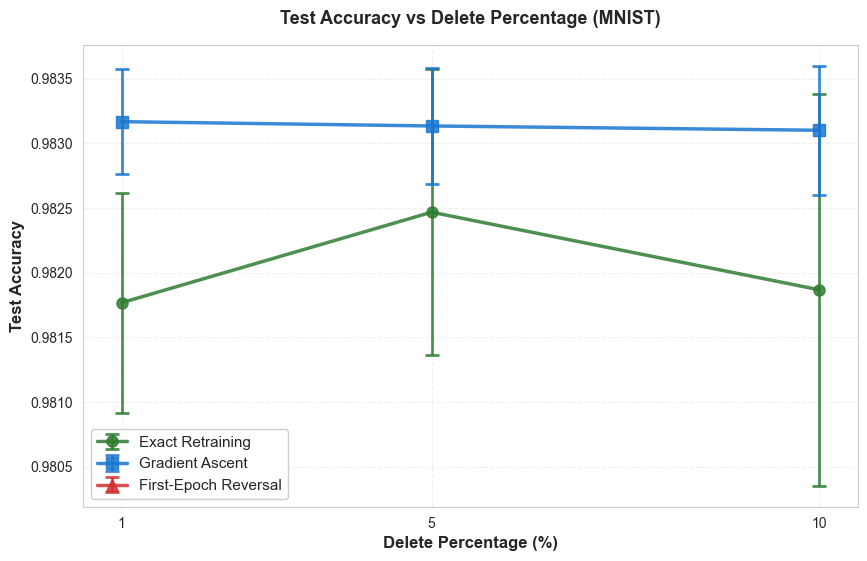

In [27]:
# PLOT 1: Test Accuracy vs Delete Percentage
print("\n[PLOT 1/3] Test Accuracy vs Delete Percentage")
plot_metric_with_errorbar(
    df,
    mean_col="test_acc_mean",
    std_col="test_acc_std",
    ylabel="Test Accuracy",
    title=f"Test Accuracy vs Delete Percentage ({SELECTED_DATASET})",
    filename=f"{SELECTED_DATASET}_plot_1_test_accuracy_vs_delete.png",
    dataset_name=SELECTED_DATASET
)


[PLOT 2/3] Retain Set Accuracy vs Delete Percentage
✓ Saved: aggregated/MNIST_plot_2_retain_accuracy_vs_delete.png


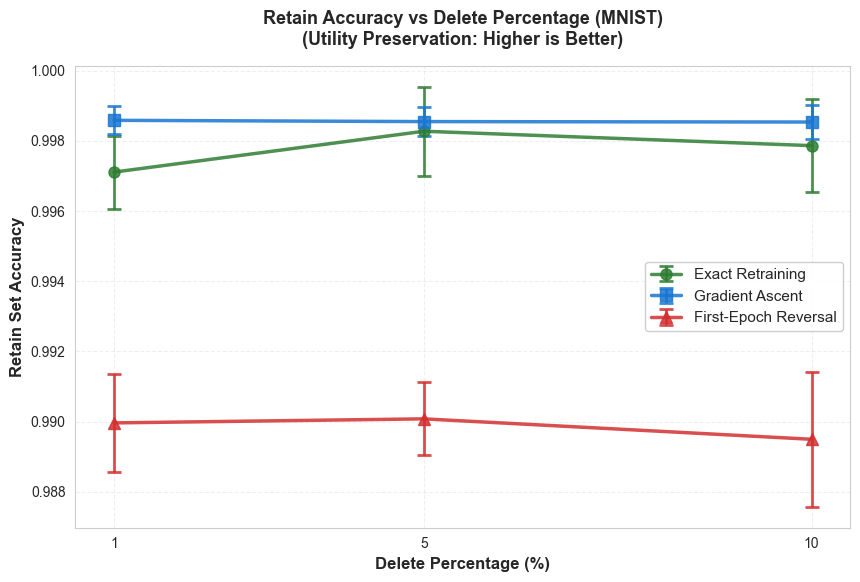

In [28]:
# PLOT 2: Retain Set Accuracy vs Delete Percentage (UTILITY)
print("\n[PLOT 2/3] Retain Set Accuracy vs Delete Percentage")
plot_metric_with_errorbar(
    df,
    mean_col="retain_acc_mean",
    std_col="retain_acc_std",
    ylabel="Retain Set Accuracy",
    title=f"Retain Accuracy vs Delete Percentage ({SELECTED_DATASET})\n(Utility Preservation: Higher is Better)",
    filename=f"{SELECTED_DATASET}_plot_2_retain_accuracy_vs_delete.png",
    dataset_name=SELECTED_DATASET
)


[PLOT 3/3] Delete Set Accuracy vs Delete Percentage
✓ Saved: aggregated/MNIST_plot_3_delete_accuracy_vs_delete.png


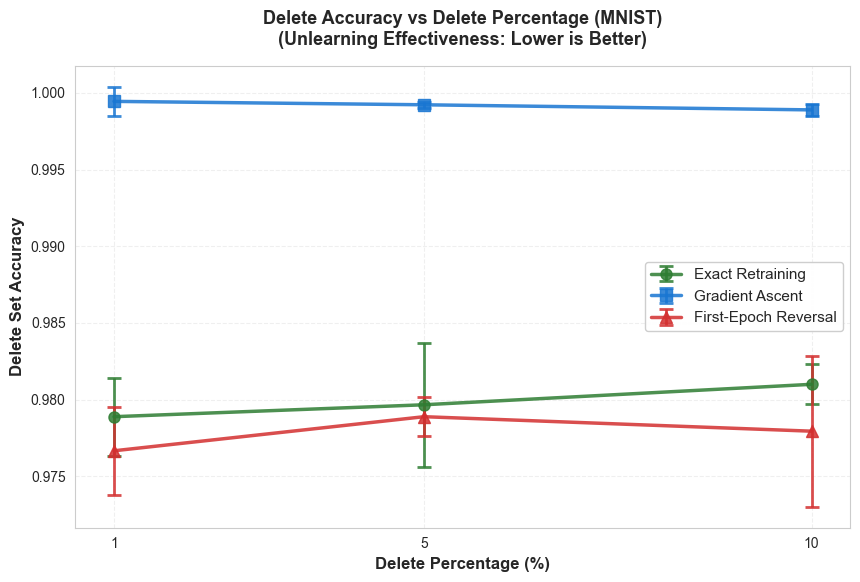


ALL PLOTS GENERATED SUCCESSFULLY

Generated files:
  - MNIST_plot_1_test_accuracy_vs_delete.png
  - MNIST_plot_2_retain_accuracy_vs_delete.png
  - MNIST_plot_3_delete_accuracy_vs_delete.png

Output directory: aggregated


In [29]:
# PLOT 3: Delete Set Accuracy vs Delete Percentage (UNLEARNING/PRIVACY)
print("\n[PLOT 3/3] Delete Set Accuracy vs Delete Percentage")
plot_metric_with_errorbar(
    df,
    mean_col="delete_acc_mean",
    std_col="delete_acc_std",
    ylabel="Delete Set Accuracy",
    title=f"Delete Accuracy vs Delete Percentage ({SELECTED_DATASET})\n(Unlearning Effectiveness: Lower is Better)",
    filename=f"{SELECTED_DATASET}_plot_3_delete_accuracy_vs_delete.png",
    dataset_name=SELECTED_DATASET
)

print("\n" + "="*80)
print("ALL PLOTS GENERATED SUCCESSFULLY")
print("="*80)
print("\nGenerated files:")
print(f"  - {SELECTED_DATASET}_plot_1_test_accuracy_vs_delete.png")
print(f"  - {SELECTED_DATASET}_plot_2_retain_accuracy_vs_delete.png")
print(f"  - {SELECTED_DATASET}_plot_3_delete_accuracy_vs_delete.png")
print(f"\nOutput directory: {AGGREGATED_OUTPUT_DIR}")


## 4. Unlearning Effectiveness Analysis


[PLOT 4/9] Forgetting Score vs Delete Percentage
✓ Saved: aggregated/MNIST_plot_4_forgetting_score_vs_delete.png


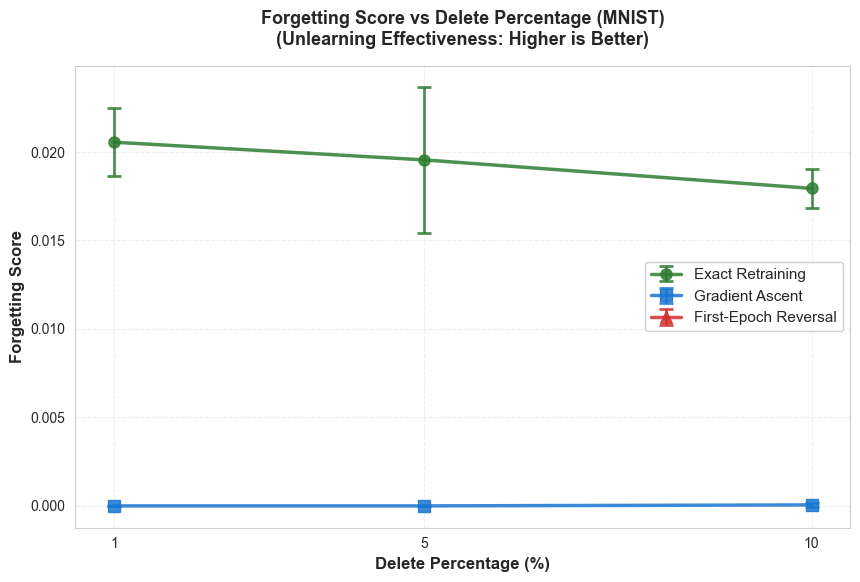

In [30]:
# PLOT 4: Forgetting Score vs Delete Percentage
print("\n[PLOT 4/9] Forgetting Score vs Delete Percentage")
plot_metric_with_errorbar(
    df,
    mean_col="forgetting_score_mean",
    std_col="forgetting_score_std",
    ylabel="Forgetting Score",
    title=f"Forgetting Score vs Delete Percentage ({SELECTED_DATASET})\n(Unlearning Effectiveness: Higher is Better)",
    filename=f"{SELECTED_DATASET}_plot_4_forgetting_score_vs_delete.png",
    dataset_name=SELECTED_DATASET
)


[PLOT 5/9] L2 Distance (Relative %) vs Delete Percentage
✓ Saved: aggregated/MNIST_plot_5_l2_distance_relative_vs_delete.png


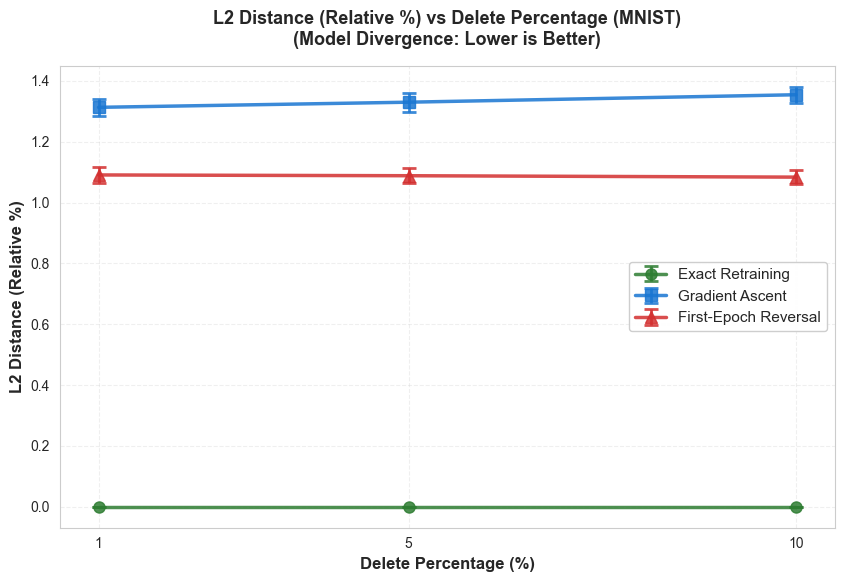

In [31]:
# PLOT 5: L2 Distance (Relative %) vs Delete Percentage
print("\n[PLOT 5/9] L2 Distance (Relative %) vs Delete Percentage")
plot_metric_with_errorbar(
    df,
    mean_col="l2_rel_mean",
    std_col="l2_rel_std",
    ylabel="L2 Distance (Relative %)",
    title=f"L2 Distance (Relative %) vs Delete Percentage ({SELECTED_DATASET})\n(Model Divergence: Lower is Better)",
    filename=f"{SELECTED_DATASET}_plot_5_l2_distance_relative_vs_delete.png",
    dataset_name=SELECTED_DATASET
)

## 5. Privacy Analysis


[PLOT 6/9] MIA Accuracy vs Delete Percentage
✓ Saved: aggregated/MNIST_plot_6_mia_accuracy_vs_delete.png


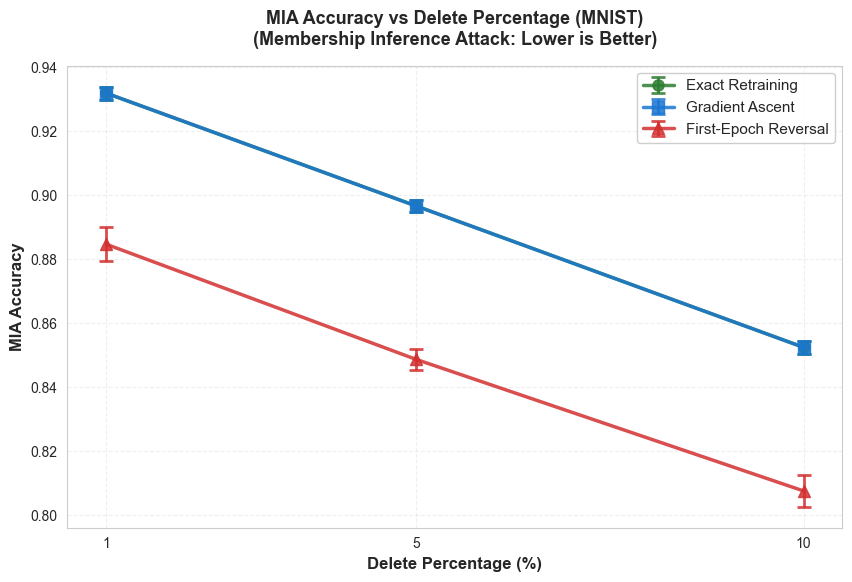

In [32]:
# PLOT 6: MIA Accuracy vs Delete Percentage
print("\n[PLOT 6/9] MIA Accuracy vs Delete Percentage")
plot_metric_with_errorbar(
    df,
    mean_col="mia_accuracy_mean",
    std_col="mia_accuracy_std",
    ylabel="MIA Accuracy",
    title=f"MIA Accuracy vs Delete Percentage ({SELECTED_DATASET})\n(Membership Inference Attack: Lower is Better)",
    filename=f"{SELECTED_DATASET}_plot_6_mia_accuracy_vs_delete.png",
    dataset_name=SELECTED_DATASET
)


[PLOT 7/9] Privacy Gain vs Delete Percentage
✓ Saved: aggregated/MNIST_plot_7_privacy_gain_vs_delete.png


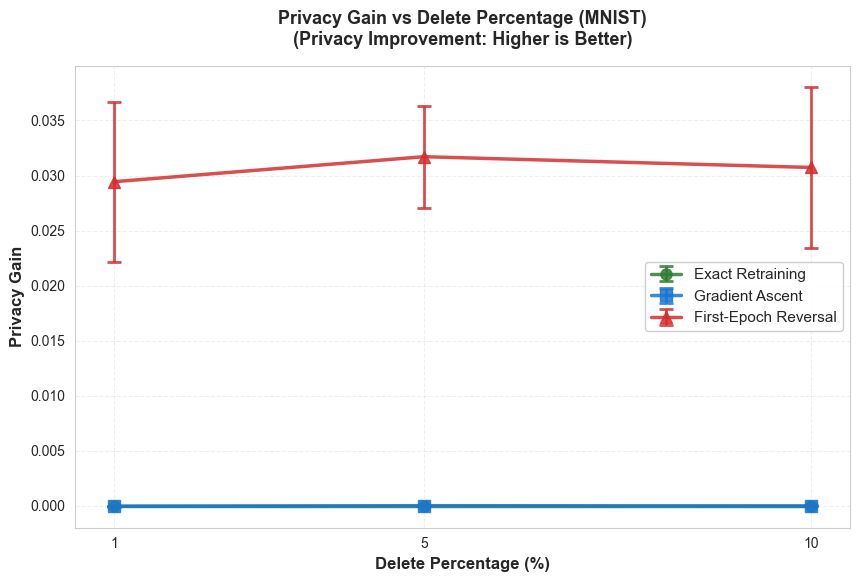

In [33]:
# PLOT 7: Privacy Gain vs Delete Percentage
print("\n[PLOT 7/9] Privacy Gain vs Delete Percentage")
plot_metric_with_errorbar(
    df,
    mean_col="privacy_gain_mean",
    std_col="privacy_gain_std",
    ylabel="Privacy Gain",
    title=f"Privacy Gain vs Delete Percentage ({SELECTED_DATASET})\n(Privacy Improvement: Higher is Better)",
    filename=f"{SELECTED_DATASET}_plot_7_privacy_gain_vs_delete.png",
    dataset_name=SELECTED_DATASET
)

## 6. Efficiency Analysis


[PLOT 8/9] Unlearning Time vs Delete Percentage
✓ Saved: aggregated/MNIST_plot_8_unlearning_time_vs_delete.png


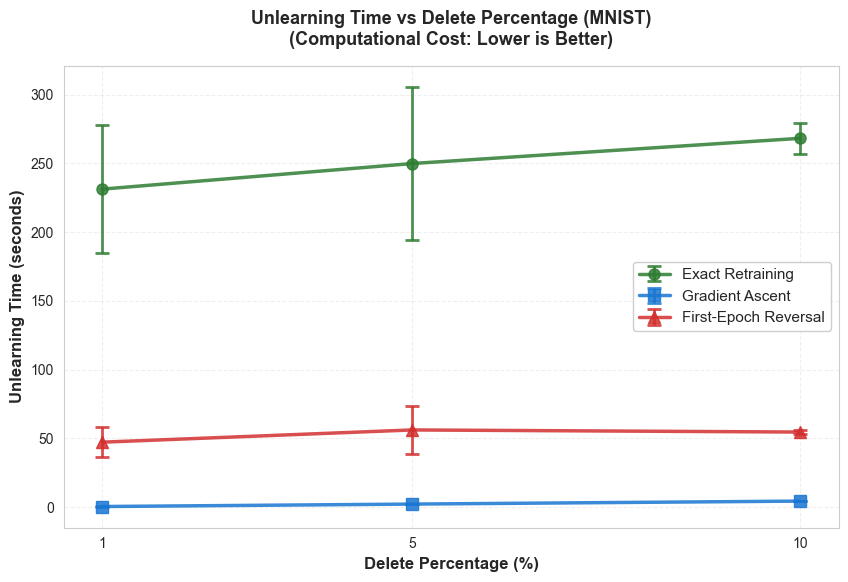

In [34]:
# PLOT 8: Unlearning Time vs Delete Percentage
print("\n[PLOT 8/9] Unlearning Time vs Delete Percentage")
plot_metric_with_errorbar(
    df,
    mean_col="time_seconds_mean",
    std_col="time_seconds_std",
    ylabel="Unlearning Time (seconds)",
    title=f"Unlearning Time vs Delete Percentage ({SELECTED_DATASET})\n(Computational Cost: Lower is Better)",
    filename=f"{SELECTED_DATASET}_plot_8_unlearning_time_vs_delete.png",
    dataset_name=SELECTED_DATASET
)


[PLOT 9/9] Speedup vs Delete Percentage
✓ Saved: aggregated/MNIST_plot_9_speedup_vs_delete.png


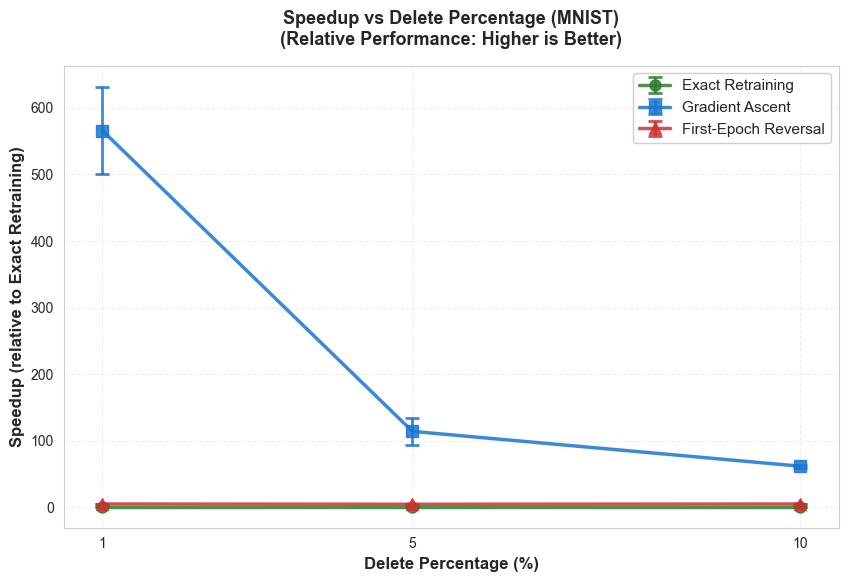


ALL 9 PLOTS GENERATED SUCCESSFULLY

Generated files:
  1. MNIST_plot_1_test_accuracy_vs_delete.png
  2. MNIST_plot_2_retain_accuracy_vs_delete.png
  3. MNIST_plot_3_delete_accuracy_vs_delete.png
  4. MNIST_plot_4_forgetting_score_vs_delete.png
  5. MNIST_plot_5_l2_distance_relative_vs_delete.png
  6. MNIST_plot_6_mia_accuracy_vs_delete.png
  7. MNIST_plot_7_privacy_gain_vs_delete.png
  8. MNIST_plot_8_unlearning_time_vs_delete.png
  9. MNIST_plot_9_speedup_vs_delete.png

Output directory: aggregated


In [35]:
# PLOT 9: Speedup vs Delete Percentage
print("\n[PLOT 9/9] Speedup vs Delete Percentage")
plot_metric_with_errorbar(
    df,
    mean_col="speedup_mean",
    std_col="speedup_std",
    ylabel="Speedup (relative to Exact Retraining)",
    title=f"Speedup vs Delete Percentage ({SELECTED_DATASET})\n(Relative Performance: Higher is Better)",
    filename=f"{SELECTED_DATASET}_plot_9_speedup_vs_delete.png",
    dataset_name=SELECTED_DATASET
)

print("\n" + "="*80)
print("ALL 9 PLOTS GENERATED SUCCESSFULLY")
print("="*80)
print("\nGenerated files:")
print(f"  1. {SELECTED_DATASET}_plot_1_test_accuracy_vs_delete.png")
print(f"  2. {SELECTED_DATASET}_plot_2_retain_accuracy_vs_delete.png")
print(f"  3. {SELECTED_DATASET}_plot_3_delete_accuracy_vs_delete.png")
print(f"  4. {SELECTED_DATASET}_plot_4_forgetting_score_vs_delete.png")
print(f"  5. {SELECTED_DATASET}_plot_5_l2_distance_relative_vs_delete.png")
print(f"  6. {SELECTED_DATASET}_plot_6_mia_accuracy_vs_delete.png")
print(f"  7. {SELECTED_DATASET}_plot_7_privacy_gain_vs_delete.png")
print(f"  8. {SELECTED_DATASET}_plot_8_unlearning_time_vs_delete.png")
print(f"  9. {SELECTED_DATASET}_plot_9_speedup_vs_delete.png")
print(f"\nOutput directory: {AGGREGATED_OUTPUT_DIR}")
print("="*80)

## 7. Advanced Comparative Analysis


[PLOT 10/14] Utility vs Forgetting Trade-off (Scatter)
✓ Saved: aggregated/MNIST_plot_10_utility_vs_forgetting.png


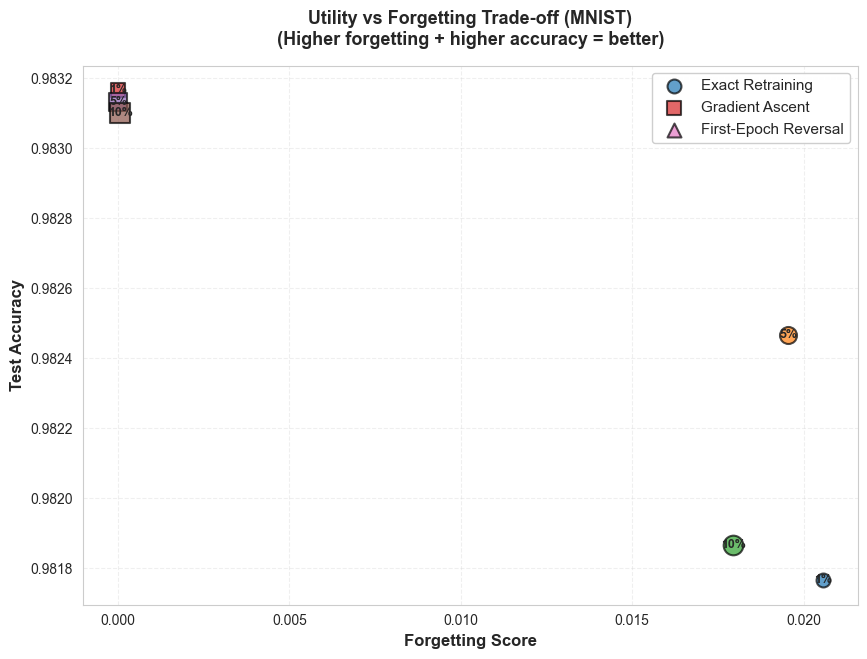

In [36]:
# PLOT 10: Scatter Plot — Utility vs Forgetting (Trade-off)
print("\n[PLOT 10/14] Utility vs Forgetting Trade-off (Scatter)")

fig, ax = plt.subplots(figsize=(10, 7))

# Define consistent markers for methods
marker_map = {
    "Exact Retraining": "o",
    "Gradient Ascent": "s",
    "First-Epoch Reversal": "^"
}

size_map = {
    0.01: 100,
    0.05: 150,
    0.10: 200
}

for method in method_order:
    method_df = df[df["method"] == method]
    
    for idx, row in method_df.iterrows():
        x = row["forgetting_score_mean"]
        y = row["test_acc_mean"]
        delete_pct = int(row["delete_ratio"] * 100)
        size = size_map.get(row["delete_ratio"], 150)
        
        ax.scatter(
            x, y,
            marker=marker_map[method],
            s=size,
            alpha=0.7,
            label=method if idx == method_df.index[0] else "",
            edgecolors="black",
            linewidth=1.5
        )
        
        # Annotate with delete percentage
        ax.annotate(
            f"{delete_pct}%",
            (x, y),
            fontsize=9,
            fontweight="bold",
            ha="center",
            va="center"
        )

ax.set_xlabel("Forgetting Score", fontsize=12, fontweight="bold")
ax.set_ylabel("Test Accuracy", fontsize=12, fontweight="bold")
ax.set_title(f"Utility vs Forgetting Trade-off ({SELECTED_DATASET})\n(Higher forgetting + higher accuracy = better)", 
             fontsize=13, fontweight="bold", pad=15)
ax.legend(loc="best", fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle="--")
ax.set_axisbelow(True)
ax.tick_params(axis="both", labelsize=10)

output_path = AGGREGATED_OUTPUT_DIR / f"{SELECTED_DATASET}_plot_10_utility_vs_forgetting.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"✓ Saved: {output_path}")

plt.show()



[PLOT 11/14] Efficiency vs Effectiveness (Time vs Forgetting)
✓ Saved: aggregated/MNIST_plot_11_efficiency_vs_effectiveness.png


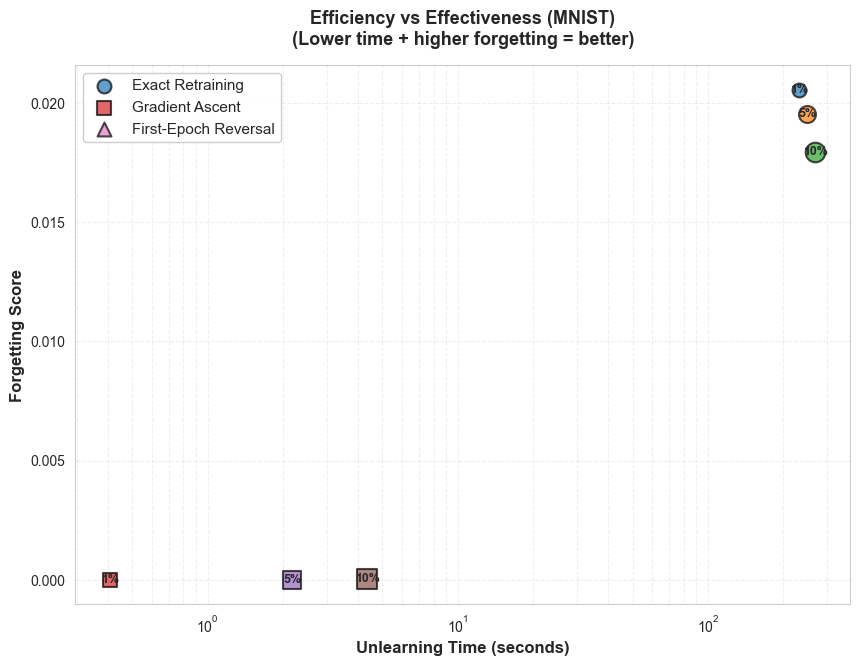

In [37]:
# PLOT 11: Scatter Plot — Efficiency vs Effectiveness
print("\n[PLOT 11/14] Efficiency vs Effectiveness (Time vs Forgetting)")

fig, ax = plt.subplots(figsize=(10, 7))

for method in method_order:
    method_df = df[df["method"] == method]
    
    for idx, row in method_df.iterrows():
        x = row["time_seconds_mean"]
        y = row["forgetting_score_mean"]
        delete_pct = int(row["delete_ratio"] * 100)
        size = size_map.get(row["delete_ratio"], 150)
        
        ax.scatter(
            x, y,
            marker=marker_map[method],
            s=size,
            alpha=0.7,
            label=method if idx == method_df.index[0] else "",
            edgecolors="black",
            linewidth=1.5
        )
        
        # Annotate with delete percentage
        ax.annotate(
            f"{delete_pct}%",
            (x, y),
            fontsize=9,
            fontweight="bold",
            ha="center",
            va="center"
        )

ax.set_xlabel("Unlearning Time (seconds)", fontsize=12, fontweight="bold")
ax.set_ylabel("Forgetting Score", fontsize=12, fontweight="bold")
ax.set_title(f"Efficiency vs Effectiveness ({SELECTED_DATASET})\n(Lower time + higher forgetting = better)", 
             fontsize=13, fontweight="bold", pad=15)
ax.set_xscale("log")
ax.legend(loc="best", fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle="--", which="both")
ax.set_axisbelow(True)
ax.tick_params(axis="both", labelsize=10)

output_path = AGGREGATED_OUTPUT_DIR / f"{SELECTED_DATASET}_plot_11_efficiency_vs_effectiveness.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"✓ Saved: {output_path}")

plt.show()



[PLOT 12/14] Summary Bar Chart — Final Comparison (10% Delete)
✓ Saved: aggregated/MNIST_plot_12_final_comparison_bar.png


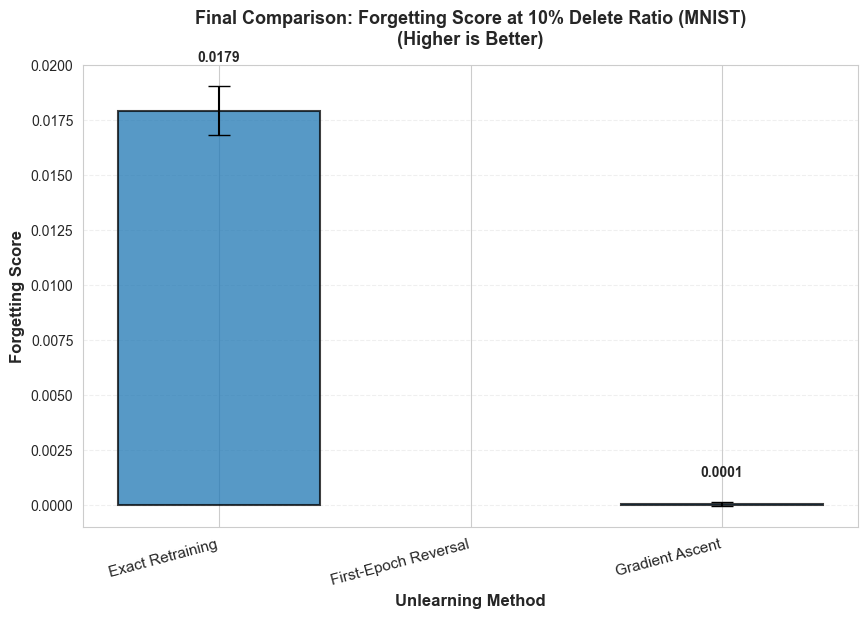

In [38]:
# PLOT 12: Summary Bar Chart — Final Comparison (10% Delete Ratio)
print("\n[PLOT 12/14] Summary Bar Chart — Final Comparison (10% Delete)")

df_final = df[df["delete_ratio"] == 0.10].copy()
df_final = df_final.sort_values("method")

fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(df_final))
y = df_final["forgetting_score_mean"].values
yerr = df_final["forgetting_score_std"].values
methods = df_final["method"].values

# Plot bars without manual color specification
bars = ax.bar(x, y, yerr=yerr, capsize=8, alpha=0.75, edgecolor="black", linewidth=1.5)

# Matplotlib will use default color cycle
ax.set_xlabel("Unlearning Method", fontsize=12, fontweight="bold")
ax.set_ylabel("Forgetting Score", fontsize=12, fontweight="bold")
ax.set_title(f"Final Comparison: Forgetting Score at 10% Delete Ratio ({SELECTED_DATASET})\n(Higher is Better)", 
             fontsize=13, fontweight="bold", pad=15)
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11, rotation=15, ha="right")
ax.grid(True, alpha=0.3, axis="y", linestyle="--")
ax.set_axisbelow(True)
ax.tick_params(axis="y", labelsize=10)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, y)):
    ax.text(bar.get_x() + bar.get_width()/2, val + yerr[i] + 0.001, 
            f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

output_path = AGGREGATED_OUTPUT_DIR / f"{SELECTED_DATASET}_plot_12_final_comparison_bar.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"✓ Saved: {output_path}")

plt.show()



[PLOT 13/14] Radar Chart — Multi-metric Comparison (10% Delete)
✓ Saved: aggregated/MNIST_plot_13_radar_multi_metric.png


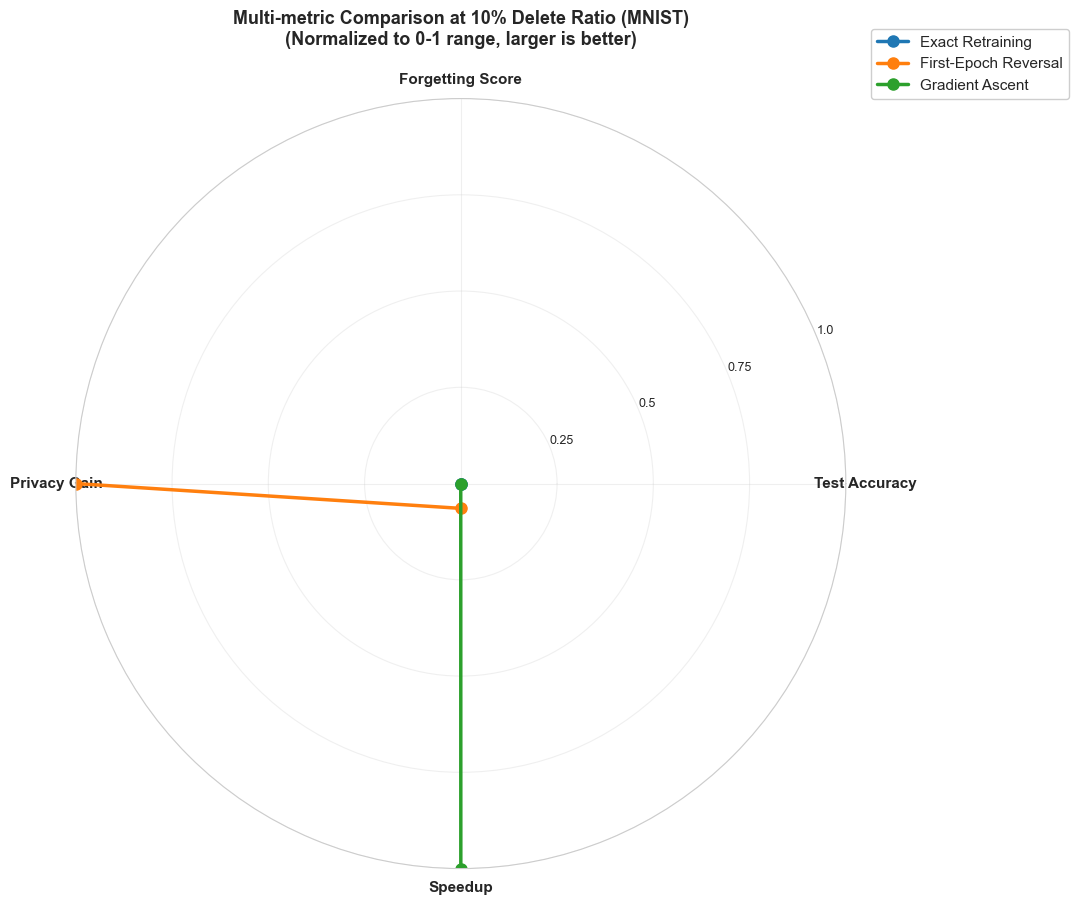

In [39]:
# PLOT 13: Radar Chart — Multi-metric Comparison (10% Delete Ratio)
print("\n[PLOT 13/14] Radar Chart — Multi-metric Comparison (10% Delete)")

from math import pi

df_radar = df[df["delete_ratio"] == 0.10].copy()
df_radar = df_radar.sort_values("method").reset_index(drop=True)

# Select metrics and normalize to 0-1 range
metrics = ["test_acc_mean", "forgetting_score_mean", "privacy_gain_mean", "speedup_mean"]
metric_labels = ["Test Accuracy", "Forgetting Score", "Privacy Gain", "Speedup"]

# Normalize each metric
normalized_data = {}
for metric in metrics:
    values = df_radar[metric].values
    min_val = values.min()
    max_val = values.max()
    
    # Handle case where min == max
    if max_val - min_val == 0:
        normalized_vals = np.ones_like(values) * 0.5
    else:
        normalized_vals = (values - min_val) / (max_val - min_val)
    
    normalized_data[metric] = normalized_vals

# Number of variables
num_vars = len(metrics)
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]  # Complete the circle

# Create radar chart
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection="polar"))

for idx, row in df_radar.iterrows():
    method = row["method"]
    values = [normalized_data[metric][idx] for metric in metrics]
    values += values[:1]  # Complete the circle
    
    ax.plot(angles, values, marker="o", linewidth=2.5, label=method, markersize=8)
    ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, fontsize=11, fontweight="bold")
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], fontsize=9)
ax.set_title(f"Multi-metric Comparison at 10% Delete Ratio ({SELECTED_DATASET})\n(Normalized to 0-1 range, larger is better)", 
             fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3)

output_path = AGGREGATED_OUTPUT_DIR / f"{SELECTED_DATASET}_plot_13_radar_multi_metric.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"✓ Saved: {output_path}")

plt.show()



[PLOT 14/14] Define reusable function for dataset comparison


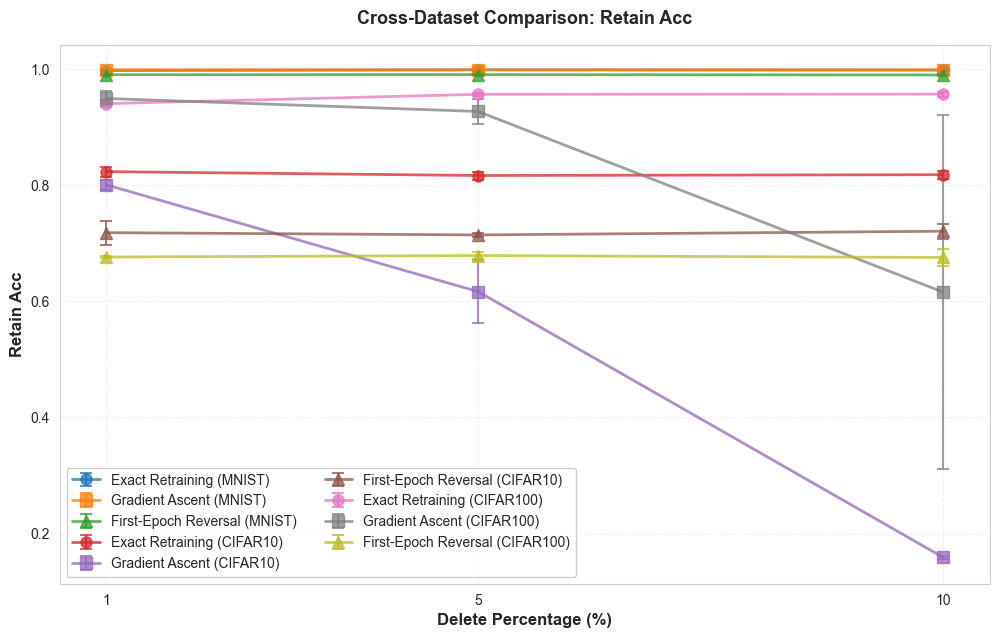

✓ Function 'plot_dataset_comparison' defined and ready to use

Example usage:
  fig, ax = plot_dataset_comparison(aggregated_data, 'retain_acc_mean', 'retain_acc_std')
  fig.savefig('output.png', dpi=300, bbox_inches='tight')


In [49]:
# PLOT 14: Reusable Function for Dataset Comparison (Not executed — for later use)
print("\n[PLOT 14/14] Define reusable function for dataset comparison")

def plot_dataset_comparison(aggregated_data, metric, std_metric=None):
    """
    Generate publication-quality plot comparing a metric across datasets and methods.
    
    Parameters:
    -----------
    aggregated_data : dict
        Dictionary with dataset names as keys and aggregated DataFrames as values.
        Each DataFrame should have columns: method, delete_ratio, and metric columns.
        
    metric : str
        Name of the metric column to plot (e.g., "retain_acc_mean").
        
    std_metric : str, optional
        Name of the standard deviation column (e.g., "retain_acc_std").
        If provided, error bars will be added.
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The generated figure object.
    """
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Define consistent markers
    marker_map = {
        "Exact Retraining": "o",
        "Gradient Ascent": "s",
        "First-Epoch Reversal": "^"
    }
    
    # Iterate over datasets and methods
    for dataset_name, df_dataset in aggregated_data.items():
        
        # Ensure methods are ordered consistently
        df_dataset = df_dataset[df_dataset["method"].isin(method_order)]
        df_dataset = df_dataset.sort_values(by=["method", "delete_ratio"])
        
        for method in method_order:
            method_data = df_dataset[df_dataset["method"] == method]
            
            if method_data.empty:
                continue
            
            x = method_data["delete_ratio"] * 100
            y = method_data[metric]
            yerr = method_data[std_metric] if std_metric and std_metric in method_data.columns else None
            
            label = f"{method} ({dataset_name})"
            
            ax.errorbar(
                x, y,
                yerr=yerr,
                marker=marker_map[method],
                markersize=8,
                linewidth=2,
                capsize=4,
                capthick=1.5,
                label=label,
                alpha=0.75,
                elinewidth=1.5
            )
    
    # Formatting
    ax.set_xlabel("Delete Percentage (%)", fontsize=12, fontweight="bold")
    ax.set_ylabel(metric.replace("_mean", "").replace("_", " ").title(), fontsize=12, fontweight="bold")
    ax.set_title(f"Cross-Dataset Comparison: {metric.replace('_mean', '').replace('_', ' ').title()}", 
                 fontsize=13, fontweight="bold", pad=15)
    ax.legend(loc="best", fontsize=10, framealpha=0.95, ncol=2)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    ax.set_xticks([1, 5, 10])
    ax.set_xlim([0.5, 10.5])
    ax.tick_params(axis="both", labelsize=10)
    
    return fig, ax

# Example usage (uncomment to run):
fig, ax = plot_dataset_comparison(aggregated_data, "retain_acc_mean", "retain_acc_std")
output_path = AGGREGATED_OUTPUT_DIR / "comparison_across_datasets_retain_accuracy.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("✓ Function 'plot_dataset_comparison' defined and ready to use")
print("\nExample usage:")
print("  fig, ax = plot_dataset_comparison(aggregated_data, 'retain_acc_mean', 'retain_acc_std')")
print("  fig.savefig('output.png', dpi=300, bbox_inches='tight')")


[PLOT 14/14] Define reusable function for dataset comparison


KeyError: 'retain_accuracy_mean'

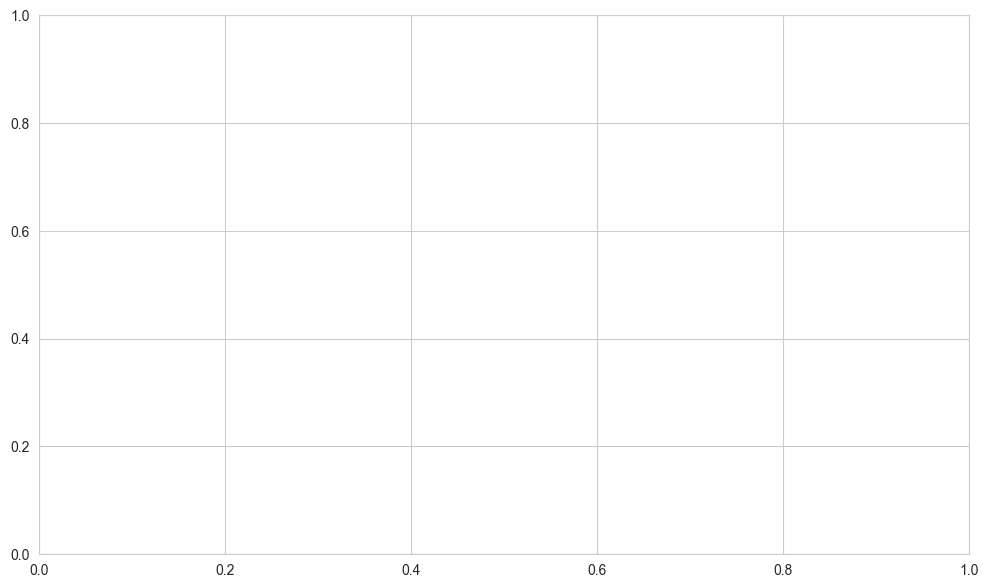

In [48]:
# PLOT 14: Reusable Function for Dataset Comparison (Not executed — for later use)
print("\n[PLOT 14/14] Define reusable function for dataset comparison")

def plot_dataset_comparison(aggregated_data, metric, std_metric=None):
    """
    Generate publication-quality plot comparing a metric across datasets and methods.
    
    Parameters:
    -----------
    aggregated_data : dict
        Dictionary with dataset names as keys and aggregated DataFrames as values.
        Each DataFrame should have columns: method, delete_ratio, and metric columns.
        
    metric : str
        Name of the metric column to plot (e.g., "retain_acc_mean").
        
    std_metric : str, optional
        Name of the standard deviation column (e.g., "retain_acc_std").
        If provided, error bars will be added.
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The generated figure object.
    """
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Define consistent markers
    marker_map = {
        "Exact Retraining": "o",
        "Gradient Ascent": "s",
        "First-Epoch Reversal": "^"
    }
    
    # Iterate over datasets and methods
    for dataset_name, df_dataset in aggregated_data.items():
        
        # Ensure methods are ordered consistently
        df_dataset = df_dataset[df_dataset["method"].isin(method_order)]
        df_dataset = df_dataset.sort_values(by=["method", "delete_ratio"])
        
        for method in method_order:
            method_data = df_dataset[df_dataset["method"] == method]
            
            if method_data.empty:
                continue
            
            x = method_data["delete_ratio"] * 100
            y = method_data[metric]
            yerr = method_data[std_metric] if std_metric and std_metric in method_data.columns else None
            
            label = f"{method} ({dataset_name})"
            
            ax.errorbar(
                x, y,
                yerr=yerr,
                marker=marker_map[method],
                markersize=8,
                linewidth=2,
                capsize=4,
                capthick=1.5,
                label=label,
                alpha=0.75,
                elinewidth=1.5
            )
    
    # Formatting
    ax.set_xlabel("Delete Percentage (%)", fontsize=12, fontweight="bold")
    ax.set_ylabel(metric.replace("_mean", "").replace("_", " ").title(), fontsize=12, fontweight="bold")
    ax.set_title(f"Cross-Dataset Comparison: {metric.replace('_mean', '').replace('_', ' ').title()}", 
                 fontsize=13, fontweight="bold", pad=15)
    ax.legend(loc="best", fontsize=10, framealpha=0.95, ncol=2)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    ax.set_xticks([1, 5, 10])
    ax.set_xlim([0.5, 10.5])
    ax.tick_params(axis="both", labelsize=10)
    
    return fig, ax

# Example usage (uncomment to run):
fig, ax = plot_dataset_comparison(aggregated_data, "retain_acc_mean", "retain_acc_std")
output_path = AGGREGATED_OUTPUT_DIR / "comparison_across_datasets_retain_accuracy.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("✓ Function 'plot_dataset_comparison' defined and ready to use")
print("\nExample usage:")
print("  fig, ax = plot_dataset_comparison(aggregated_data, 'retain_acc_mean', 'retain_acc_std')")
print("  fig.savefig('output.png', dpi=300, bbox_inches='tight')")

## 8. Baseline Model Comparison Across Datasets


MNIST baseline comparison
dataset  seed  baseline_test_acc                            source_file
  MNIST    42             0.9831 unlearning_seed_0042_0.01_results.json
  MNIST   123             0.9836 unlearning_seed_0123_0.01_results.json
  MNIST   999             0.9828 unlearning_seed_0999_0.01_results.json
Mean test accuracy: 0.9832
Std test accuracy:  0.0004

CIFAR10 baseline comparison
dataset  seed  baseline_test_acc                                    source_file
CIFAR10    42             0.6335 CIFAR10_unlearning_seed_0042_0.01_results.json
CIFAR10   123             0.6346 CIFAR10_unlearning_seed_0123_0.01_results.json
CIFAR10   999             0.6424 CIFAR10_unlearning_seed_0999_0.01_results.json
Mean test accuracy: 0.6368
Std test accuracy:  0.0049

CIFAR100 baseline comparison
 dataset  seed  baseline_test_acc                                     source_file
CIFAR100    42             0.3189 CIFAR100_unlearning_seed_0042_0.01_results.json
CIFAR100   123             0.3136 

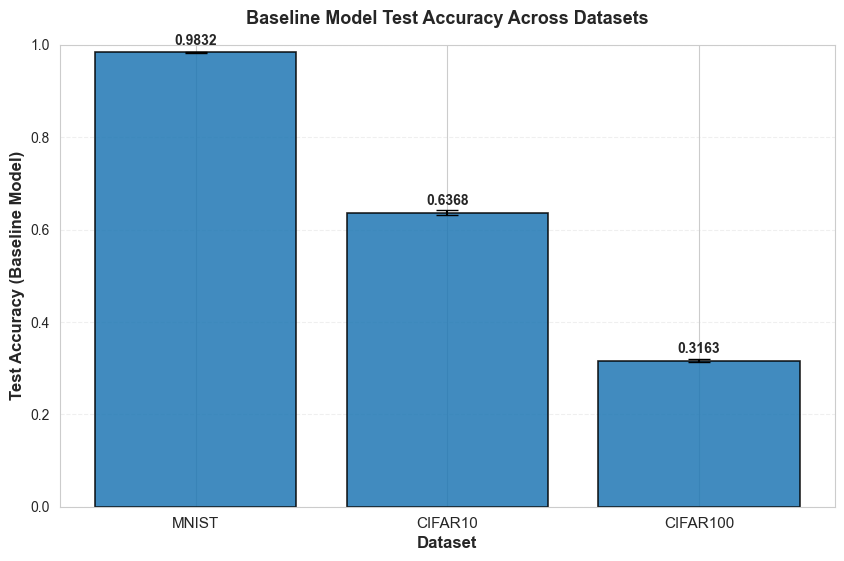

In [43]:
import re

def load_baseline_test_accuracy(results_dir, dataset_tag, seed_list):
    """Load one baseline test accuracy per seed for a dataset."""
    prefix = "" if dataset_tag.upper() == "MNIST" else f"{dataset_tag}_"
    pattern = f"{prefix}unlearning_seed_*_results.json"
    seed_to_value = {}
    seed_to_file = {}

    for path in sorted(results_dir.glob(pattern)):
        match = re.search(r"seed_(\d{4})_", path.name)
        if not match:
            continue
        seed = int(match.group(1))
        if seed not in seed_list or seed in seed_to_value:
            continue

        with path.open('r') as f:
            data = json.load(f)

        baseline = data.get('baseline_model', {})
        test_acc = baseline.get('test_accuracy', baseline.get('test_acc'))
        if test_acc is not None:
            seed_to_value[seed] = float(test_acc)
            seed_to_file[seed] = path.name

    rows = []
    for seed in seed_list:
        if seed in seed_to_value:
            rows.append({
                'dataset': dataset_tag,
                'seed': seed,
                'baseline_test_acc': seed_to_value[seed],
                'source_file': seed_to_file[seed],
            })

    return pd.DataFrame(rows)

baseline_rows = []
for dataset_name in DATASETS:
    df_baseline = load_baseline_test_accuracy(RESULTS_DIR, dataset_name, SEEDS)
    if df_baseline.empty:
        print(f'\n⚠ No baseline test accuracy values found for {dataset_name}')
        continue

    baseline_mean = df_baseline['baseline_test_acc'].mean()
    baseline_std = df_baseline['baseline_test_acc'].std()
    baseline_rows.append({
        'dataset': dataset_name,
        'baseline_test_acc_mean': baseline_mean,
        'baseline_test_acc_std': baseline_std,
        'n_seeds': len(df_baseline),
    })

    print(f'\n{dataset_name} baseline comparison')
    print(df_baseline.sort_values('seed').to_string(index=False))
    print(f"Mean test accuracy: {baseline_mean:.4f}")
    print(f"Std test accuracy:  {baseline_std:.4f}")

baseline_comparison_df = pd.DataFrame(baseline_rows)
baseline_comparison_df = baseline_comparison_df.set_index('dataset').reindex(DATASETS).reset_index()

print('\n' + '=' * 80)
print('Baseline comparison summary')
print('=' * 80)
print(baseline_comparison_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(baseline_comparison_df))
y = baseline_comparison_df['baseline_test_acc_mean'].values
yerr = baseline_comparison_df['baseline_test_acc_std'].fillna(0).values

bars = ax.bar(x, y, yerr=yerr, capsize=8, alpha=0.85, edgecolor='black', linewidth=1.2)
ax.set_xticks(x)
ax.set_xticklabels(baseline_comparison_df['dataset'], fontsize=11)
ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax.set_ylabel('Test Accuracy (Baseline Model)', fontsize=12, fontweight='bold')
ax.set_title('Baseline Model Test Accuracy Across Datasets', fontsize=13, fontweight='bold', pad=15)
ax.grid(True, axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.tick_params(axis='y', labelsize=10)
ax.set_ylim(0, min(1.0, max(y + yerr) + 0.05))

for bar, value in zip(bars, y):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{value:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

baseline_plot_path = AGGREGATED_OUTPUT_DIR / 'baseline_test_accuracy_by_dataset.png'
fig.savefig(baseline_plot_path, dpi=300, bbox_inches='tight')
print(f'\n✓ Saved baseline comparison plot: {baseline_plot_path}')
plt.show()


Comparison summary at delete_pct=10%
 dataset  Test Accuracy  Retain Accuracy  Unlearning Time (s)
   MNIST       0.982483         0.995298           109.070189
 CIFAR10       0.395600         0.565810           124.669827
CIFAR100       0.261583         0.749143           113.947134

Normalized comparison summary at delete_pct=10% (0-1 scale)
 dataset  Test Accuracy  Retain Accuracy  Unlearning Time (s)
   MNIST       1.000000         1.000000             1.000000
 CIFAR10       0.185902         0.000000             0.000000
CIFAR100       0.000000         0.426864             0.687368


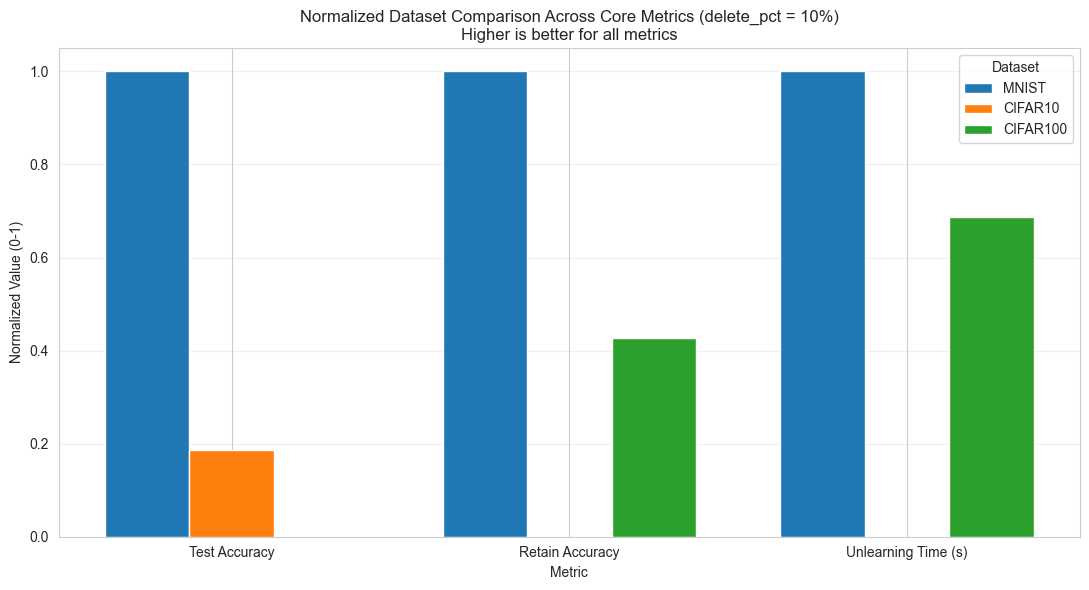

Saved grouped bar chart to: aggregated/dataset_metric_grouped_bar_delete10_retain_accuracy_normalized.png


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset-level grouped bar chart for thesis comparison
# We summarize each dataset at delete_pct = 10% using the existing aggregated results.
selected_delete_pct = 10
selected_delete_ratio = selected_delete_pct / 100.0

dataset_order = ["MNIST", "CIFAR10", "CIFAR100"]
metric_specs = [
    ("test_acc_mean", "Test Accuracy", False),
    ("retain_acc_mean", "Retain Accuracy", False),
    ("time_seconds_mean", "Unlearning Time (s)", True),
]

comparison_rows = []
for dataset_name in dataset_order:
    if dataset_name not in aggregated_data:
        print(f"Skipping missing dataset: {dataset_name}")
        continue

    df_dataset = aggregated_data[dataset_name].copy()
    df_selected = df_dataset[np.isclose(df_dataset["delete_ratio"], selected_delete_ratio)].copy()

    if df_selected.empty:
        print(f"No rows found for {dataset_name} at delete_pct={selected_delete_pct}%")
        continue

    comparison_rows.append({
        "dataset": dataset_name,
        "Test Accuracy": float(df_selected["test_acc_mean"].mean()),
        "Retain Accuracy": float(df_selected["retain_acc_mean"].mean()),
        "Unlearning Time (s)": float(df_selected["time_seconds_mean"].mean()),
    })

comparison_df = pd.DataFrame(comparison_rows)
print(f"Comparison summary at delete_pct={selected_delete_pct}%")
print(comparison_df.to_string(index=False))

# Normalize each metric to 0-1 so all three can be shown on one graph.
# Time is inverted so higher normalized values still mean better performance.
normalized_df = comparison_df.copy()
for metric_col, metric_label, invert in metric_specs:
    values = normalized_df[metric_label].astype(float)
    min_val = values.min()
    max_val = values.max()

    if np.isclose(max_val, min_val):
        normalized_values = np.ones_like(values, dtype=float) * 0.5
    elif invert:
        normalized_values = (max_val - values) / (max_val - min_val)
    else:
        normalized_values = (values - min_val) / (max_val - min_val)

    normalized_df[metric_label] = normalized_values

print(f"\nNormalized comparison summary at delete_pct={selected_delete_pct}% (0-1 scale)")
print(normalized_df.to_string(index=False))

plot_metrics = [label for _, label, _ in metric_specs]
x = np.arange(len(plot_metrics))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
for idx, dataset_name in enumerate(dataset_order):
    row = normalized_df[normalized_df["dataset"] == dataset_name]
    if row.empty:
        continue

    values = row.iloc[0][plot_metrics].values.astype(float)
    offset = (idx - (len(dataset_order) - 1) / 2) * bar_width
    ax.bar(x + offset, values, bar_width, label=dataset_name)

ax.set_xlabel("Metric")
ax.set_ylabel("Normalized Value (0-1)")
ax.set_title("Normalized Dataset Comparison Across Core Metrics (delete_pct = 10%)\nHigher is better for all metrics")
ax.set_xticks(x)
ax.set_xticklabels(plot_metrics)
ax.legend(title="Dataset")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()

output_path = AGGREGATED_OUTPUT_DIR / "dataset_metric_grouped_bar_delete10_retain_accuracy_normalized.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved grouped bar chart to: {output_path}")